<a href="https://colab.research.google.com/github/AgapovKS/Generation-tasks-in-NLP_HW2/blob/main/HW_NLP_TASK_2_Agapov_KS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Зависимости
!pip -q install -U kagglehub datasets transformers accelerate peft bitsandbytes trl sentencepiece matplotlib pandas tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 re

In [2]:
# все импорты
import os
import gc
import re
import json
import math
import torch
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig,
    TrainingArguments,
)

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig

import kagglehub

# все необходимые настройки для кода и для воспроизводимости
SEED = 42
torch.manual_seed(SEED)

# Папки
BASE_DIR = "./yoda_ru_qwen"
os.makedirs(BASE_DIR, exist_ok=True)

# Размер батча для перевода
TRANSLATE_BATCH_SIZE = 16

## 1. Загрузка и обработка датасета

In [3]:
# загрузка датасета
dataset_path = kagglehub.dataset_download("stefanocoretta/yoda-speech-corpus")
file_path = os.path.join(dataset_path, "yoda-corpus.csv")
df = pd.read_csv(file_path)

print('Столбцы:')
print(df.columns)

100%|██████████| 14.8k/14.8k [00:00<00:00, 4.67MB/s]

Extracting files...
Столбцы:
Index(['movie', 'scene', 'line', 'character', 'text', 'slug', 'component'], dtype='str')


In [4]:
#Пример строк
df.head()

,movie,scene,line,character,text,slug,component
0,1,129,1158,narrator,QUI-GON stands in a tall stately room. Twelve ...,INT. TEMPLE OF THE JEDI - COUNCIL CHAMBERS - DAY,action
1,1,129,1159,QUI-GON,...my only conclusion can be that it was a Sit...,INT. TEMPLE OF THE JEDI - COUNCIL CHAMBERS - DAY,character
2,1,129,1160,MACE WINDU,A Sith Lord?!?,INT. TEMPLE OF THE JEDI - COUNCIL CHAMBERS - DAY,character
3,1,129,1161,KI-ADI,Impossible! The Sith have been extinct for a m...,INT. TEMPLE OF THE JEDI - COUNCIL CHAMBERS - DAY,character
4,1,129,1162,YODA,"The very Republic is threatened, if involved t...",INT. TEMPLE OF THE JEDI - COUNCIL CHAMBERS - DAY,character


In [5]:
# Нас интересуют только строки: character == "YODA"
# и только столбец text
yoda_df = df.loc[
    df["character"].astype(str).str.upper().eq("YODA"),
    ["character", "text"]
].copy()

In [6]:
yoda_df["text"] = yoda_df["text"].astype(str).str.strip()
yoda_df = yoda_df[yoda_df["text"].notna()]
yoda_df = yoda_df[yoda_df["text"] != ""]
yoda_df = yoda_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Кол-во строк в датасете:", len(yoda_df))
print(yoda_df.head(10))

Кол-во строк в датасете: 99
  character                                               text
0      YODA  The very Republic is threatened, if involved t...
1      YODA  Hard to see, the dark side is. Discover who th...
2      YODA  With this Naboo queen you must stay, Qui-Gon. ...
3      YODA                         May the Force be with you.
4      YODA      (Cont'd) Master Qui-Gon more to say have you?
5      YODA                               A vergence, you say?
6      YODA             But you do! Rrevealed your opinion is.
7      YODA            Trained as a Jedi, you request for him?
8      YODA                                 Tested he will be.
9      YODA               Good, good, young one. How feel you?


Строк не так много, для передачи стиля персонажа, понадобится побольше эпох (4+)

## 2. Перевод датасета на русский язык

Поскольку исходный датасет на английском, его необходимо перевести на русский

In [7]:
# Используем готовую модель перевода английский -> русский.
translation_model_name = "Helsinki-NLP/opus-mt-en-ru"

translator_tokenizer = AutoTokenizer.from_pretrained(translation_model_name)
translator_model = AutoModelForSeq2SeqLM.from_pretrained(
    translation_model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
).to("cuda" if torch.cuda.is_available() else "cpu")

translator_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/307M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/307M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(62518, 512, padding_idx=62517)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(62518, 512, padding_idx=62517)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [8]:
def translate_batch(texts, max_length=1024):
    """
    Переводит список английских строк на русский.
    """
    inputs = translator_tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024,
    ).to(translator_model.device)

    with torch.no_grad():
        generated = translator_model.generate(
            **inputs,
            max_new_tokens=max_length,
            num_beams=4,
        )

    return translator_tokenizer.batch_decode(generated, skip_special_tokens=True)


In [9]:
translated_texts = []

for i in tqdm(range(0, len(yoda_df), TRANSLATE_BATCH_SIZE), desc="Translating"):
    batch = yoda_df["text"].iloc[i:i + TRANSLATE_BATCH_SIZE].tolist()
    translated_batch = translate_batch(batch)
    translated_texts.extend(translated_batch)

yoda_df["text_ru"] = translated_texts

# Чистка после перевода
yoda_df["text_ru"] = (
    yoda_df["text_ru"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

yoda_df = yoda_df[yoda_df["text_ru"].notna()]
yoda_df = yoda_df[yoda_df["text_ru"] != ""].reset_index(drop=True)

print(yoda_df.head(10))

# Сохраним переведённый датасет
translated_csv_path = os.path.join(BASE_DIR, "yoda_translated_ru.csv")
yoda_df.to_csv(translated_csv_path, index=False, encoding="utf-8")
print("Переведенный датасет сохранен в:", translated_csv_path)

Translating:   0%|          | 0/7 [00:00<?, ?it/s]

Both `max_new_tokens` (=1024) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  character                                               text  \
0      YODA  The very Republic is threatened, if involved t...   
1      YODA  Hard to see, the dark side is. Discover who th...   
2      YODA  With this Naboo queen you must stay, Qui-Gon. ...   
3      YODA                         May the Force be with you.   
4      YODA      (Cont'd) Master Qui-Gon more to say have you?   
5      YODA                               A vergence, you say?   
6      YODA             But you do! Rrevealed your opinion is.   
7      YODA            Trained as a Jedi, you request for him?   
8      YODA                                 Tested he will be.   
9      YODA               Good, good, young one. How feel you?   

                                             text_ru  
0  Сама Республика находится под угрозой, если в ...  
1  Сложно видеть, темная сторона в том, что мы до...  
2  С этой королевой Набу ты должен остаться, Кви-...  
3                           Пусть Силы будут с вами. 

In [10]:
# Освободим память от переводчика
del translator_model
del translator_tokenizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 3. Подготовка данных для Finetuning модели

In [11]:
# Cоздаём instruction-format структуру, чтобы  модель отвечала в стиле Йоды по-русски.

prompt_templates = [
    "Ответь как Йода на русском языке.",
    "Скажи это в стиле Йоды по-русски.",
    "Перефразируй как мудрый Йода на русском.",
    "Сохрани стиль Йоды и ответь по-русски.",
]

def build_training_text(example, idx):
    prompt = prompt_templates[idx % len(prompt_templates)]
    messages = [
        {
            "role": "system",
            "content": "Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски."
        },
        {
            "role": "user",
            "content": prompt
        },
        {
            "role": "assistant",
            "content": example["text_ru"]
        },
    ]
    return messages

# Загружаем обратно через datasets
ds = Dataset.from_pandas(yoda_df[["text_ru"]].rename(columns={"text_ru": "response"}))

Воспользуемся моделью Qwen: она компактная, открытая и с поддержкой русского языка

In [12]:
# Загружаем токенизатор Qwen заранее, чтобы использовать chat template
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
def formatting_func(example):
    text = example["response"]
    idx = formatting_func.counter
    formatting_func.counter += 1

    prompt = prompt_templates[idx % len(prompt_templates)]
    messages = [
        {
            "role": "system",
            "content": "Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски."
        },
        {
            "role": "user",
            "content": prompt
        },
        {
            "role": "assistant",
            "content": text
        },
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

formatting_func.counter = 0

In [14]:
# Разделим на train / eval
split = ds.train_test_split(test_size=0.05, seed=SEED)
train_ds = split["train"]
eval_ds = split["test"]

print(train_ds[0])

{'response': 'Надеюсь, вы правы, а теперь разрушьте армии дроидов на Кашийке, я сделаю это.'}


## 4. Lora

In [15]:
use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
compute_dtype = torch.bfloat16 if use_bf16 else torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

base_model = prepare_model_for_kbit_training(base_model)
base_model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 5. Finetuning модели

In [16]:
# Конфиг
training_args = SFTConfig(
    output_dir=os.path.join(BASE_DIR, "qwen_yoda_ru_adapter"),

    num_train_epochs=6,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,
    warmup_steps=10,

    logging_steps=5,
    eval_steps=20,
    save_steps=50,
    save_total_limit=2,

    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",

    bf16=True,
    fp16=False,

    gradient_checkpointing=True,
    report_to="none",
    seed=SEED,

    max_length=512,   #
)


# форматирование

def formatting_func(example):
    text = example["response"]

    messages = [
        {
            "role": "system",
            "content": "Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски."
        },
        {
            "role": "user",
            "content": "Ответь как Йода."
        },
        {
            "role": "assistant",
            "content": text
        },
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

# Trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
    formatting_func=formatting_func,
)

# обучение
trainer.train()

#Сохраняем адаптер
adapter_dir = os.path.join(BASE_DIR, "qwen_yoda_ru_adapter")

trainer.model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)

print("Адаптер сохранен в:", adapter_dir)

Applying formatting function to train dataset:   0%|          | 0/94 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/94 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/94 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/94 [00:00<?, ? examples/s]

Applying formatting function to eval dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
5,3.471616
10,2.163416
15,1.088658
20,0.831592
25,0.646499
30,0.603250
35,0.678721
40,0.504288
45,0.558124
50,0.481204


Адаптер сохранен в: ./yoda_ru_qwen/qwen_yoda_ru_adapter


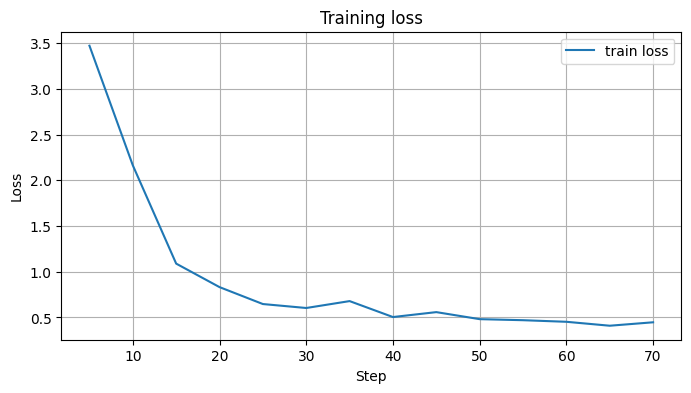

График сохранен в: ./yoda_ru_qwen/training_logs.csv


In [17]:
# график Loss
logs = pd.DataFrame(trainer.state.log_history)

loss_df = logs[logs["loss"].notna()][["step", "loss"]].copy() if "loss" in logs.columns else pd.DataFrame()
eval_df = logs[logs["eval_loss"].notna()][["step", "eval_loss"]].copy() if "eval_loss" in logs.columns else pd.DataFrame()

plt.figure(figsize=(8, 4))
plt.plot(loss_df["step"], loss_df["loss"], label="train loss")
if len(eval_df) > 0:
    plt.plot(eval_df["step"], eval_df["eval_loss"], label="eval loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.show()

# Сохраним логи для отчёта
logs_path = os.path.join(BASE_DIR, "training_logs.csv")
logs.to_csv(logs_path, index=False)
print("График сохранен в:", logs_path)

#№ 6. инференс: base модель vs модель после fine-tuning


In [18]:
def build_prompt(user_text: str):
    messages = [
        {
            "role": "system",
            "content": "Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски."
        },
        {
            "role": "user",
            "content": user_text
        }
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def generate_answer(model, tokenizer, user_text, max_new_tokens=120, temperature=0.8, top_p=0.9):
    prompt = build_prompt(user_text)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return decoded

In [22]:
# Базовая модель без адаптера
base_for_infer = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

test_prompts = [
    "Что такое сила?",
    "В чем смысл жизни?",
    "Что есть мы",
    "Как говорит кошка",
]

print("\n Базовая модель: \n")
for p in test_prompts:
    print("Пользователь:", p)
    print(generate_answer(base_for_infer, tokenizer, p, max_new_tokens=80))
    print("-" * 80)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


 Базовая модель: 

Пользователь: Что такое сила?
system
Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски.
user
Что такое сила?
assistant
Сила — это способность делать или управлять что-либо или кто-то, обычно в определенное время и место. Это может быть физическая, эмоциональная или мысленная. Форма силы также зависит от контекста: например, физическая сила (мощь), интеллектуальная сила
--------------------------------------------------------------------------------
Пользователь: В чем смысл жизни?
system
Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски.
user
В чем смысл жизни?
assistant
Смысл жизни - это внутренняя цель, которая дает человеку уверенность в своей деятельности и способности делать что-то важное. Он помогает преодолевать трудности и улучшать мир вокруг нас. Важно найти то, что заставляет тебя радоваться и двигаться вперед каждый день.
---------------------------------------------------------------------

Как можно увидеть нет ни странного порядка слов, ни понимание контекста персонажа ("сила")

In [23]:
# Модель с адаптером
ft_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(ft_model, adapter_dir)

print("\n Дообученная модель: \n")
for p in test_prompts:
    print("USER:", p)
    print(generate_answer(ft_model, tokenizer, p, max_new_tokens=80))
    print("-" * 80)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


 Дообученная модель: 

USER: Что такое сила?
system
Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски.
user
Что такое сила?
assistant
Силой называется мощь, которую вы можете использовать в своих целях.
--------------------------------------------------------------------------------
USER: В чем смысл жизни?
system
Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски.
user
В чем смысл жизни?
assistant
Мы должны дать жизнь новым возможностям, мы должны дать людям больше, чем они могут себе позволить, нам нужно быть тем, кем ты говорил мне - учеником, который должен научиться учится.
--------------------------------------------------------------------------------
USER: Что есть мы
system
Ты говоришь как Йода: мудро, кратко и с необычным порядком слов. Отвечай по-русски.
user
Что есть мы
assistant
Больше никаких тренировок, больше никакого уничтожения джедаев.
-------------------------------------------------------------------

Стиль переняла, тк видно странный порядок слов. Однако видно, что модель странно отвечает, тк данных была мало, также сама модель маленькая

In [21]:
# Функция инференса
def chat():
    print("Введите вопрос. Для выхода напишите 'exit'.")
    while True:
        user_text = input("\Вы: ").strip()
        if user_text.lower() == "exit":
            break
        answer = generate_answer(ft_model, tokenizer, user_text, max_new_tokens=120)
        print("\Йода:", answer)

# нужно расскоментировать строчку ниже
#chat()

Пример работы


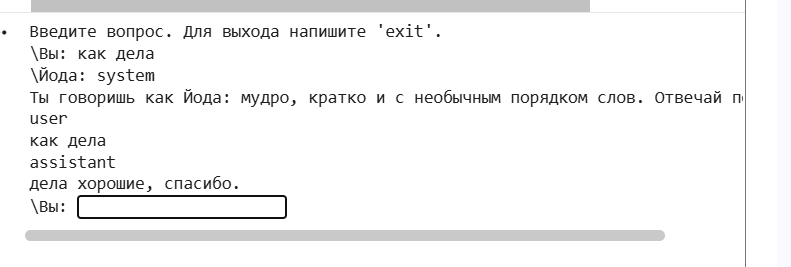